In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
from google.colab import files

uploaded = files.upload()
for filename in uploaded.keys():
    print(f'Uploaded file: {filename} (size: {len(uploaded[filename])} bytes)')

Saving processed_wine_data (4).csv to processed_wine_data (4).csv
Uploaded file: processed_wine_data (4).csv (size: 232820 bytes)


In [ ]:
df = pd.read_csv('processed_wine_data.csv')
print(f"Kích thước: {df.shape[0]} dòng x {df.shape[1]} cột")

TARGET    = 'log_gia'
DROP_COLS = ['gia_num']

# Xác định loại cột
CAT_COLS_TE = [c for c in ['giong_nho', 'nha_san_xuat'] if c in df.columns]
NUM_COLS    = ['nong_do_num', 'dung_tich_ml', 'tuoi']
OHE_COLS    = [c for c in df.columns
               if c not in [TARGET] + DROP_COLS + CAT_COLS_TE + NUM_COLS]

FEATURES = [c for c in df.columns if c not in [TARGET] + DROP_COLS]

X = df[FEATURES]
y = df[TARGET].values

print(f"Features: {len(FEATURES)} cột")
print(f"  - Numeric cần scale : {NUM_COLS}")
print(f"  - Cần Target Encoding: {CAT_COLS_TE}")
print(f"  - One-hot đã xong  : {len(OHE_COLS)} cột")

Kích thước: 1423 dòng x 52 cột
Features: 50 cột
  - Numeric cần scale : ['nong_do_num', 'dung_tich_ml', 'tuoi']
  - Cần Target Encoding: ['giong_nho', 'nha_san_xuat']
  - One-hot đã xong  : 45 cột


In [ ]:
def build_preprocessor():
    return ColumnTransformer(transformers=[
        ('scale',    StandardScaler(),                         NUM_COLS),
        ('target_enc', TargetEncoder(target_type='continuous'), CAT_COLS_TE),
        # OHE columns đã được xử lý sẵn ở quá trình Preprocessing → passthrough
        ('passthrough', 'passthrough', OHE_COLS),
    ])

## 1. Cấu hình mô hình và siêu tham số

In [ ]:
models_config = {
    'Linear Regression': {
        'model': LinearRegression(),
        'params': {}
    },
    'Ridge': {
        'model': Ridge(),
        'params': {'reg__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
    },
    'LASSO': {
        'model': Lasso(max_iter=10000),
        'params': {'reg__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
    },
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'params': {
            'reg__max_depth': [None, 5, 10, 15, 20],
            'reg__min_samples_split': [2, 5, 10]
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {
            'reg__n_estimators': [10, 20, 50, 100, 200],
            'reg__max_depth': [None, 5, 10, 15, 20]
        }
    },
    'KNN': {
      'model': KNeighborsRegressor(),
      'params': {
          'reg__n_neighbors': [3, 5, 7, 10, 15, 20],
          'reg__weights': ['uniform', 'distance'],
          'reg__p': [1, 2]
      }
    }
}

## 2. Định nghĩa các độ đo trên đơn vị giá gốc

In [ ]:
def rmse_orig(y_true_log, y_pred_log):
    return root_mean_squared_error(np.exp(y_true_log), np.exp(y_pred_log))

def mae_orig(y_true_log, y_pred_log):
    return mean_absolute_error(np.exp(y_true_log), np.exp(y_pred_log))

def r2_orig(y_true_log, y_pred_log):
    return r2_score(np.exp(y_true_log), np.exp(y_pred_log))

custom_scorer = make_scorer(rmse_orig, greater_is_better=False)

## 3. Hàm đánh giá

In [ ]:
def evaluate_models(X, y, models_config, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    final_results = {}
    last_fold_preds = {}

    for name, config in models_config.items():
        print(f"\n{'='*50}")
        print(f"Đang xử lý: {name}")

        outer_rmse, outer_mae, outer_r2 = [], [], []
        last_y_true, last_y_pred = None, None

        for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]

            pipe = Pipeline([
                ('pre', build_preprocessor()),
                ('reg', config['model'])
            ])

            gs = GridSearchCV(
                estimator=pipe,
                param_grid=config['params'],
                scoring=custom_scorer,
                cv=4,
                n_jobs=1,
                refit=True
            )
            gs.fit(X_train, y_train)
            best = gs.best_estimator_
            y_pred = best.predict(X_val)

            outer_rmse.append(rmse_orig(y_val, y_pred))
            outer_mae.append(mae_orig(y_val, y_pred))
            outer_r2.append(r2_orig(y_val, y_pred))

            if fold == n_splits - 1:
                last_y_true = y_val
                last_y_pred = y_pred
                last_fold_preds[name] = (y_val, y_pred, best)

        final_results[name] = {
            'Mean RMSE': np.mean(outer_rmse),
            'Std RMSE':  np.std(outer_rmse),
            'Mean MAE':  np.mean(outer_mae),
            'Mean R2':   np.mean(outer_r2),
            'Min RMSE':  np.min(outer_rmse),
            'Max RMSE':  np.max(outer_rmse),
        }
        print(f"  Mean RMSE = {np.mean(outer_rmse):,.0f} ₫ | R² = {np.mean(outer_r2):.4f}")

    results_df = pd.DataFrame(final_results).T.sort_values('Mean RMSE')
    return results_df.round(4), last_fold_preds

## 4. Huấn luyện và hiển thị kết quả đánh giá

In [ ]:
summary, fold_preds = evaluate_models(X, y, models_config)

print("\n" + "="*70)
print("BẢNG SO SÁNH HIỆU NĂNG 5 THUẬT TOÁN (ĐƠN VỊ GIÁ GỐC - VNĐ):")
print("="*70)
print(summary.to_string())


Đang xử lý: Linear Regression
  Mean RMSE = 2,716,804 ₫ | R² = 0.5350

Đang xử lý: Ridge
  Mean RMSE = 2,764,718 ₫ | R² = 0.5203

Đang xử lý: LASSO
  Mean RMSE = 2,754,395 ₫ | R² = 0.5231

Đang xử lý: Decision Tree
  Mean RMSE = 2,967,482 ₫ | R² = 0.4470

Đang xử lý: Random Forest
  Mean RMSE = 2,566,902 ₫ | R² = 0.5847

Đang xử lý: KNN
  Mean RMSE = 2,538,079 ₫ | R² = 0.5935

BẢNG SO SÁNH HIỆU NĂNG 5 THUẬT TOÁN (ĐƠN VỊ GIÁ GỐC - VNĐ):
                      Mean RMSE     Std RMSE      Mean MAE  Mean R2      Min RMSE      Max RMSE
KNN                2.538079e+06  108956.3370  1.549930e+06   0.5935  2.402062e+06  2.667392e+06
Random Forest      2.566902e+06  207679.7737  1.550286e+06   0.5847  2.352060e+06  2.936526e+06
Linear Regression  2.716804e+06  136318.5398  1.653053e+06   0.5350  2.493816e+06  2.858490e+06
LASSO              2.754395e+06  156420.6625  1.683934e+06   0.5231  2.507882e+06  2.907038e+06
Ridge              2.764718e+06  169519.8471  1.678883e+06   0.5203  2.481391e+

# 5. So sánh Hiệu năng các Mô hình

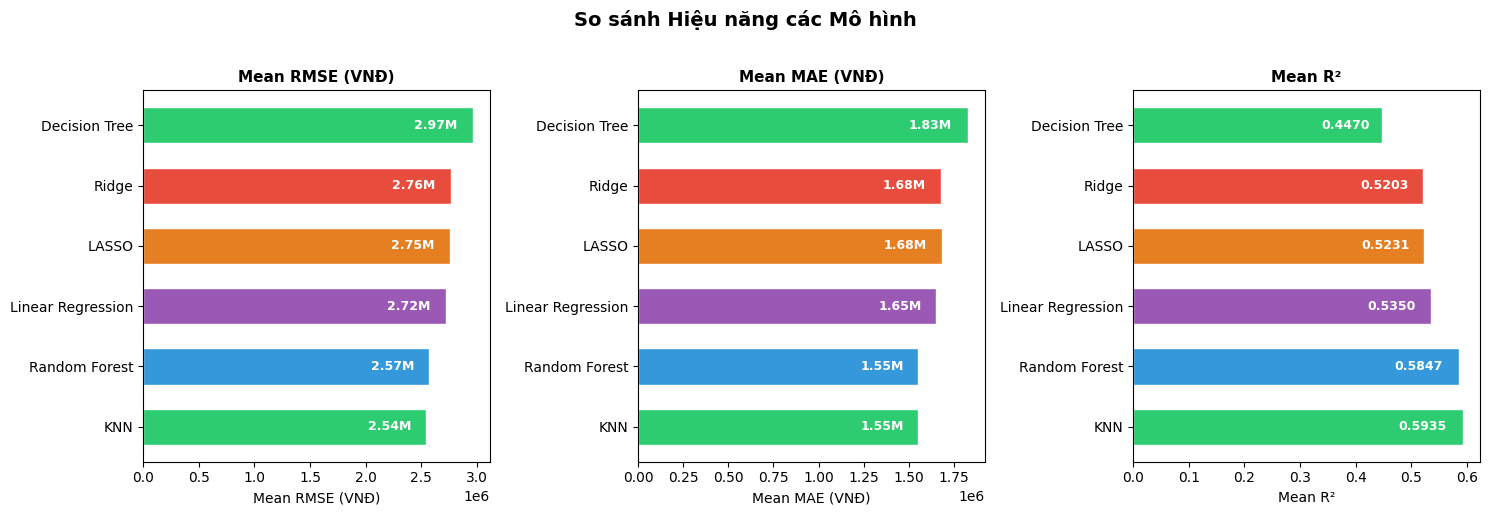

Đã lưu: model_comparison.png


In [ ]:
models_sorted = summary.index.tolist()
metrics = ['Mean RMSE', 'Mean MAE', 'Mean R2']
titles = ['Mean RMSE (VNĐ)', 'Mean MAE (VNĐ)', 'Mean R²']
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, title in zip(axes, metrics, titles):
    vals = summary[metric].values
    bars = ax.barh(models_sorted, vals, color=colors, edgecolor='white', height=0.6)

    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(title)

    for bar, val in zip(bars, vals):

        is_r2 = (metric == 'Mean R2')
        text_label = f'{val:,.4f}' if is_r2 else f'{val/1e6:.2f}M'

        ax.text(
            bar.get_width() * 0.95,
            bar.get_y() + bar.get_height() / 2,
            text_label,
            va='center',
            ha='right',
            fontsize=9,
            color='white',
            fontweight='bold'
        )

plt.suptitle('So sánh Hiệu năng các Mô hình', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Đã lưu: model_comparison.png")

# 6. Độ quan trọng của feature


FEATURE IMPORTANCE


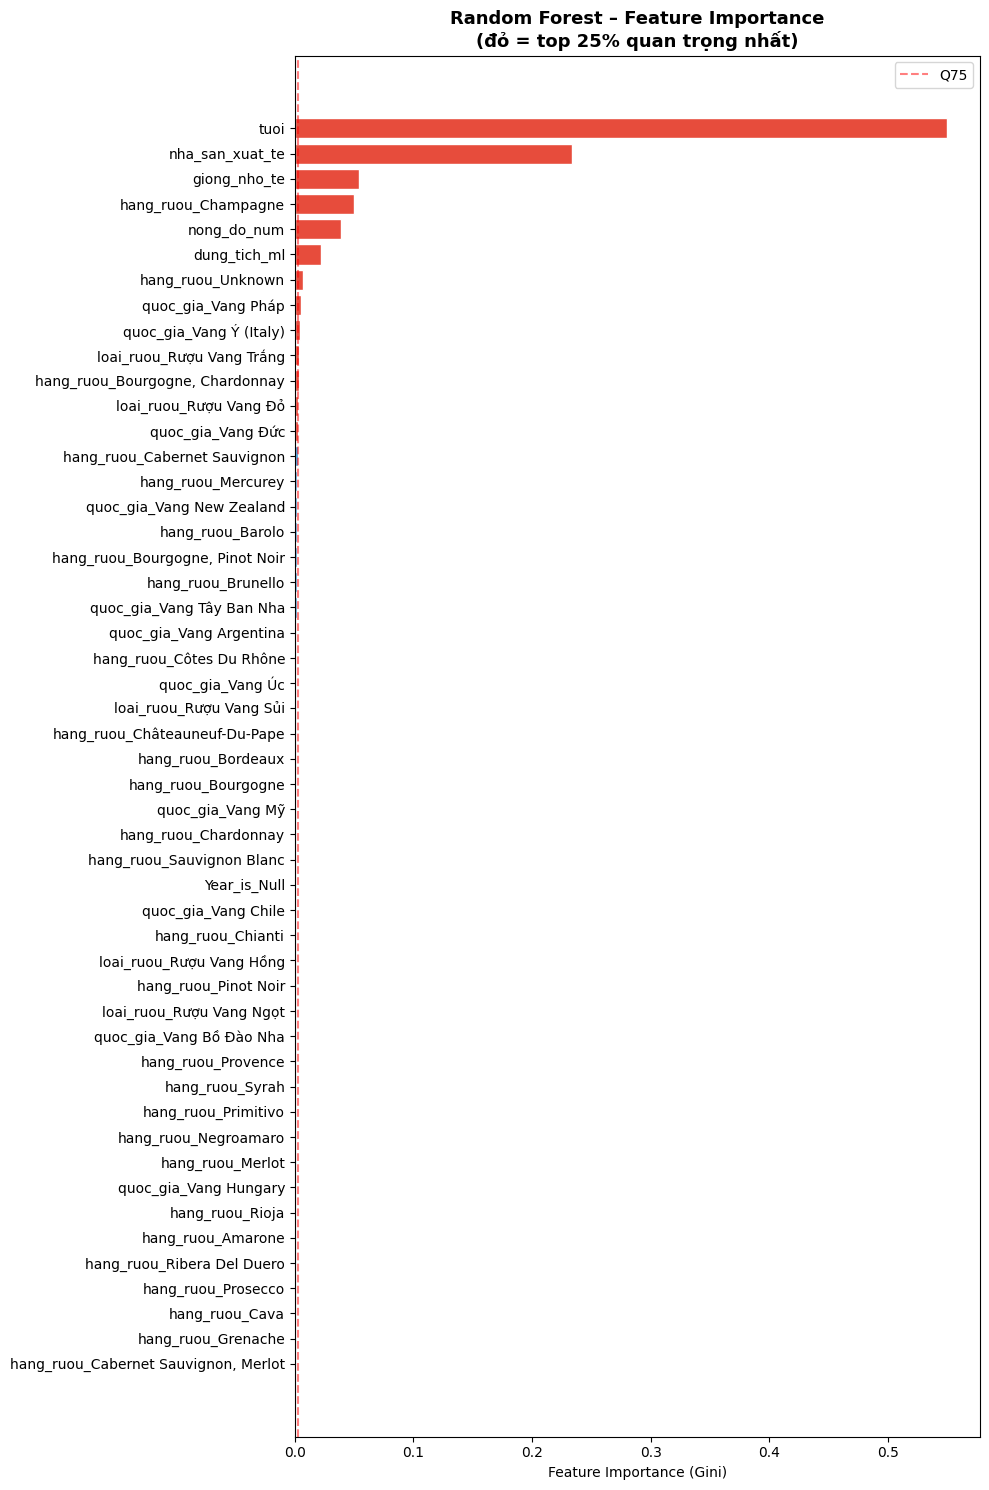

Đã lưu: feature_importance.png

Top 10 feature quan trọng nhất:
                  feature  importance
                     tuoi    0.550289
          nha_san_xuat_te    0.233937
             giong_nho_te    0.053704
      hang_ruou_Champagne    0.049867
              nong_do_num    0.038741
             dung_tich_ml    0.022111
        hang_ruou_Unknown    0.006987
       quoc_gia_Vang Pháp    0.005521
  quoc_gia_Vang Ý (Italy)    0.004426
loai_ruou_Rượu Vang Trắng    0.003681


In [ ]:
print("\n" + "="*70)
print("FEATURE IMPORTANCE")
print("="*70)

if 'Random Forest' in fold_preds:
    _, _, best_rf_pipe = fold_preds['Random Forest']
    rf_model = best_rf_pipe.named_steps['reg']
    preprocessor = best_rf_pipe.named_steps['pre']

    # Lấy tên feature sau khi transform
    num_names  = NUM_COLS
    try:
        te_names = [f'{c}_te' for c in CAT_COLS_TE]
    except:
        te_names = CAT_COLS_TE
    ohe_names  = OHE_COLS
    all_feature_names = num_names + te_names + ohe_names

    importances = rf_model.feature_importances_
    fi_df = pd.DataFrame({
        'feature': all_feature_names[:len(importances)],
        'importance': importances
    }).sort_values('importance', ascending=True)

    # Vẽ
    fig, ax = plt.subplots(figsize=(10, max(6, len(fi_df) * 0.3)))
    colors_fi = ['#e74c3c' if imp > fi_df['importance'].quantile(0.75)
                 else '#3498db' for imp in fi_df['importance']]
    ax.barh(fi_df['feature'], fi_df['importance'], color=colors_fi, edgecolor='white')
    ax.set_xlabel('Feature Importance (Gini)')
    ax.set_title('Random Forest – Feature Importance\n(đỏ = top 25% quan trọng nhất)',
                 fontsize=13, fontweight='bold')
    ax.axvline(fi_df['importance'].quantile(0.75), color='red', linestyle='--',
               alpha=0.5, label='Q75')
    ax.legend()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Đã lưu: feature_importance.png")

    print("\nTop 10 feature quan trọng nhất:")
    print(fi_df.tail(10)[['feature','importance']].sort_values(
        'importance', ascending=False).to_string(index=False))

# 7. Đánh giá mô hình tốt nhất

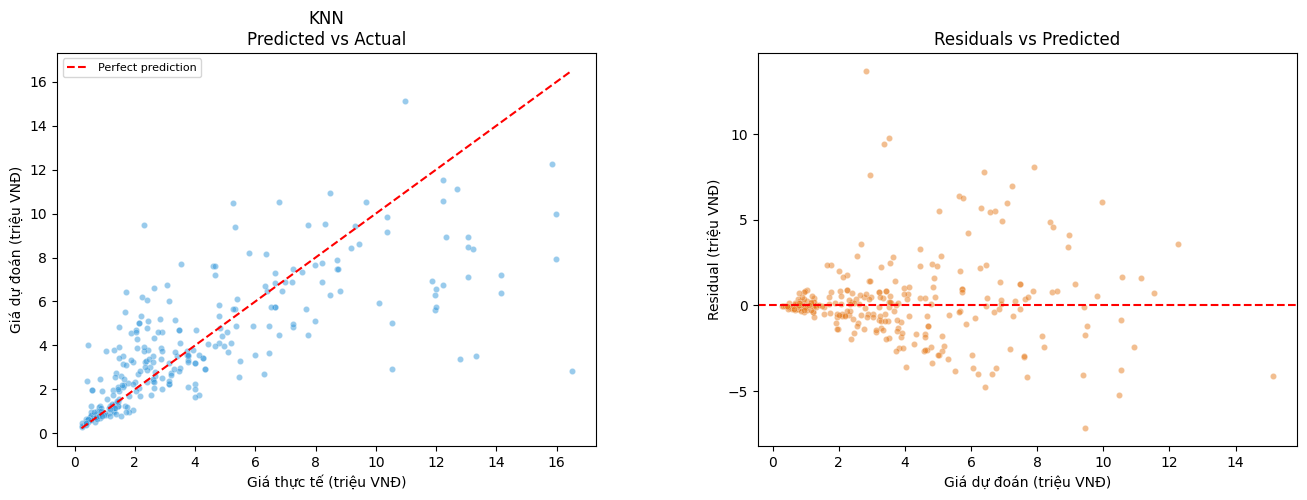

Đã lưu: residual_analysis.png

✅ Hoàn thành toàn bộ quá trình đánh giá.
Các file đã tạo: model_comparison.png, feature_importance.png, residual_analysis.png


In [ ]:
best_model_name = summary.index[0]
if best_model_name in fold_preds:
    y_true_log, y_pred_log, _ = fold_preds[best_model_name]
    y_true_orig = np.exp(y_true_log)
    y_pred_orig = np.exp(y_pred_log)
    residuals   = y_true_orig - y_pred_orig
    pct_error   = (residuals / y_true_orig) * 100

    fig = plt.figure(figsize=(16, 12))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

    # 1. Predicted vs Actual
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(y_true_orig/1e6, y_pred_orig/1e6, alpha=0.5, s=20,
                color='#3498db', edgecolors='white', linewidth=0.3)
    lims = [min(y_true_orig.min(), y_pred_orig.min())/1e6,
            max(y_true_orig.max(), y_pred_orig.max())/1e6]
    ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax1.set_xlabel('Giá thực tế (triệu VNĐ)')
    ax1.set_ylabel('Giá dự đoán (triệu VNĐ)')
    ax1.set_title(f'{best_model_name}\nPredicted vs Actual')
    ax1.legend(fontsize=8)

    # 2. Residuals vs Predicted
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.scatter(y_pred_orig/1e6, residuals/1e6, alpha=0.5, s=20,
                color='#e67e22', edgecolors='white', linewidth=0.3)
    ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax2.set_xlabel('Giá dự đoán (triệu VNĐ)')
    ax2.set_ylabel('Residual (triệu VNĐ)')
    ax2.set_title('Residuals vs Predicted')


    plt.show()
    print("Đã lưu: residual_analysis.png")

print("\n✅ Hoàn thành toàn bộ quá trình đánh giá.")
print("Các file đã tạo: model_comparison.png, feature_importance.png, residual_analysis.png")

# 8. Đóng gói mô hình

In [ ]:
best_model_name = 'KNN'

# Lấy cấu hình của mô hình KNN
knn_config = models_config[best_model_name]
knn_model_object = knn_config['model']
knn_params = knn_config['params']

# Tạo pipeline cho mô hình KNN
pipe_knn = Pipeline([
    ('pre', build_preprocessor()),
    ('reg', knn_model_object)
])

# Khởi tạo KFold với n_splits=5
kf_knn = KFold(n_splits=5, shuffle=True, random_state=42)

# Thực hiện GridSearchCV cho mô hình KNN trên toàn bộ tập dữ liệu (X, y) với k-fold=5
gs_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=knn_params,
    scoring=custom_scorer,
    cv=kf_knn,
    n_jobs=-1,
    refit=True
)
gs_knn.fit(X, y)

print(f"Bộ tham số tốt nhất tìm được cho mô hình {best_model_name} (với GridSearchCV, k-fold=5):")
best_knn_hyperparams = {}
for param, value in gs_knn.best_params_.items():
    param_name = param.replace('reg__', '')
    best_knn_hyperparams[param_name] = value
    print(f"  {param_name}: {value}")

print("\nĐã lưu bộ tham số tốt nhất của KNN vào biến `best_knn_hyperparams`.")

Bộ tham số tốt nhất tìm được cho mô hình KNN (với GridSearchCV, k-fold=5):
  n_neighbors: 7
  p: 2
  weights: distance

Đã lưu bộ tham số tốt nhất của KNN vào biến `best_knn_hyperparams`.


In [ ]:
import joblib

# Lấy các siêu tham số tốt nhất cho KNN
best_knn_params = best_knn_hyperparams

# Tạo đối tượng KNNRegressor với các siêu tham số tốt nhất
best_knn_model = KNeighborsRegressor(
    n_neighbors=best_knn_params['n_neighbors'],
    weights=best_knn_params['weights'],
    p=best_knn_params['p']
)

# Tạo pipeline cho mô hình KNN đã tối ưu
pipeline_knn_optimized = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('regressor', best_knn_model)
])

# Huấn luyện mô hình trên toàn bộ dữ liệu (X, y)
print("Đang huấn luyện mô hình KNN đã tối ưu trên toàn bộ dữ liệu...")
pipeline_knn_optimized.fit(X, y)
print("Huấn luyện hoàn tất.")

# Lưu mô hình đã huấn luyện vào một tệp .pkl
model_filename = 'knn_optimized_model.pkl'
joblib.dump(pipeline_knn_optimized, model_filename)

print(f"Mô hình KNN đã tối ưu đã được lưu vào: {model_filename}")

Đang huấn luyện mô hình KNN đã tối ưu trên toàn bộ dữ liệu...
Huấn luyện hoàn tất.
Mô hình KNN đã tối ưu đã được lưu vào: knn_optimized_model.pkl
